## 1. Import Dataset

In [ ]:
import sys
import pandas as pd
sys.path.append('..')

from src.db_connector import fetch_data

dataset = fetch_data("SELECT * FROM e_commerce_dataset_e_comm")

dataset.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,160
1,50002,1,,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0,1,0,121
2,50003,1,,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0,1,3,120
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134
4,50005,1,0,Phone,1,12,CC,Male,,3,Mobile,5,Single,3,0,11,1,1,3,130


## 2. Check Information Dataset

In [22]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   CustomerID                   5630 non-null   int64
 1   Churn                        5630 non-null   int64
 2   Tenure                       5630 non-null   str  
 3   PreferredLoginDevice         5630 non-null   str  
 4   CityTier                     5630 non-null   int64
 5   WarehouseToHome              5630 non-null   str  
 6   PreferredPaymentMode         5630 non-null   str  
 7   Gender                       5630 non-null   str  
 8   HourSpendOnApp               5630 non-null   str  
 9   NumberOfDeviceRegistered     5630 non-null   int64
 10  PreferedOrderCat             5630 non-null   str  
 11  SatisfactionScore            5630 non-null   int64
 12  MaritalStatus                5630 non-null   str  
 13  NumberOfAddress              5630 non-null   int64
 14  Com

## 3. Check Null Value

In [23]:
import numpy as np

dataset.replace(r'^\s*$', np.nan, regex=True, inplace=True)

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Mobile Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1,1,5,160
1,50002,1,NaN,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0,1,0,121
2,50003,1,NaN,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0,1,3,120
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0,1,3,134
4,50005,1,0,Phone,1,12,CC,Male,NaN,3,Mobile,5,Single,3,0,11,1,1,3,130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10,Computer,1,30,Credit Card,Male,3,2,Laptop & Accessory,1,Married,6,0,18,1,2,4,151
5626,55627,0,13,Mobile Phone,1,13,Credit Card,Male,3,5,Fashion,5,Married,6,0,16,1,2,NaN,225
5627,55628,0,1,Mobile Phone,1,11,Debit Card,Male,3,2,Laptop & Accessory,4,Married,3,1,21,1,2,4,186
5628,55629,0,23,Computer,3,9,Credit Card,Male,4,5,Laptop & Accessory,4,Married,4,0,15,2,2,9,179


In [24]:
dataset.isnull().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

## 4. Viewing the Histogram

In [25]:
print(f"Shape: {dataset.shape}")

Shape: (5630, 20)


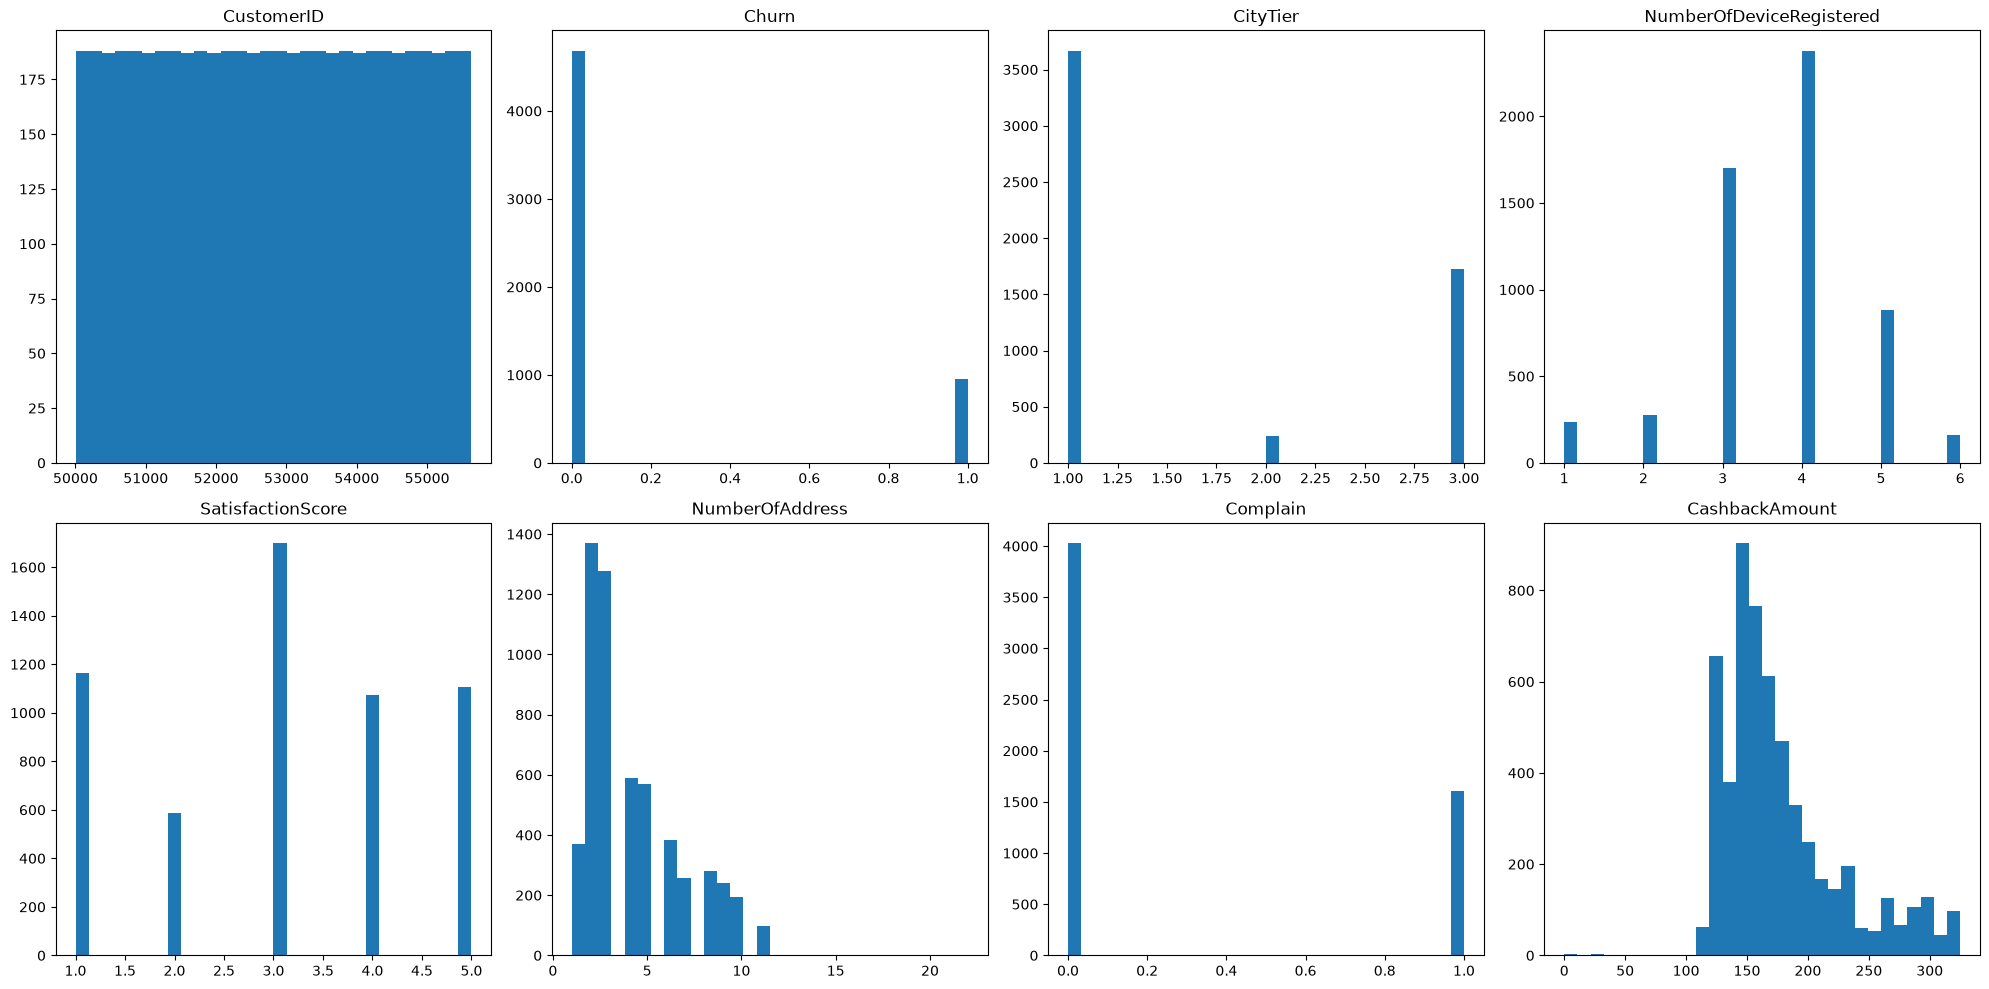

In [26]:
import math
import matplotlib.pyplot as plt

num_cols = dataset.select_dtypes(include='number').columns
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(dataset[col], bins=30)
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 5. Check Outlier

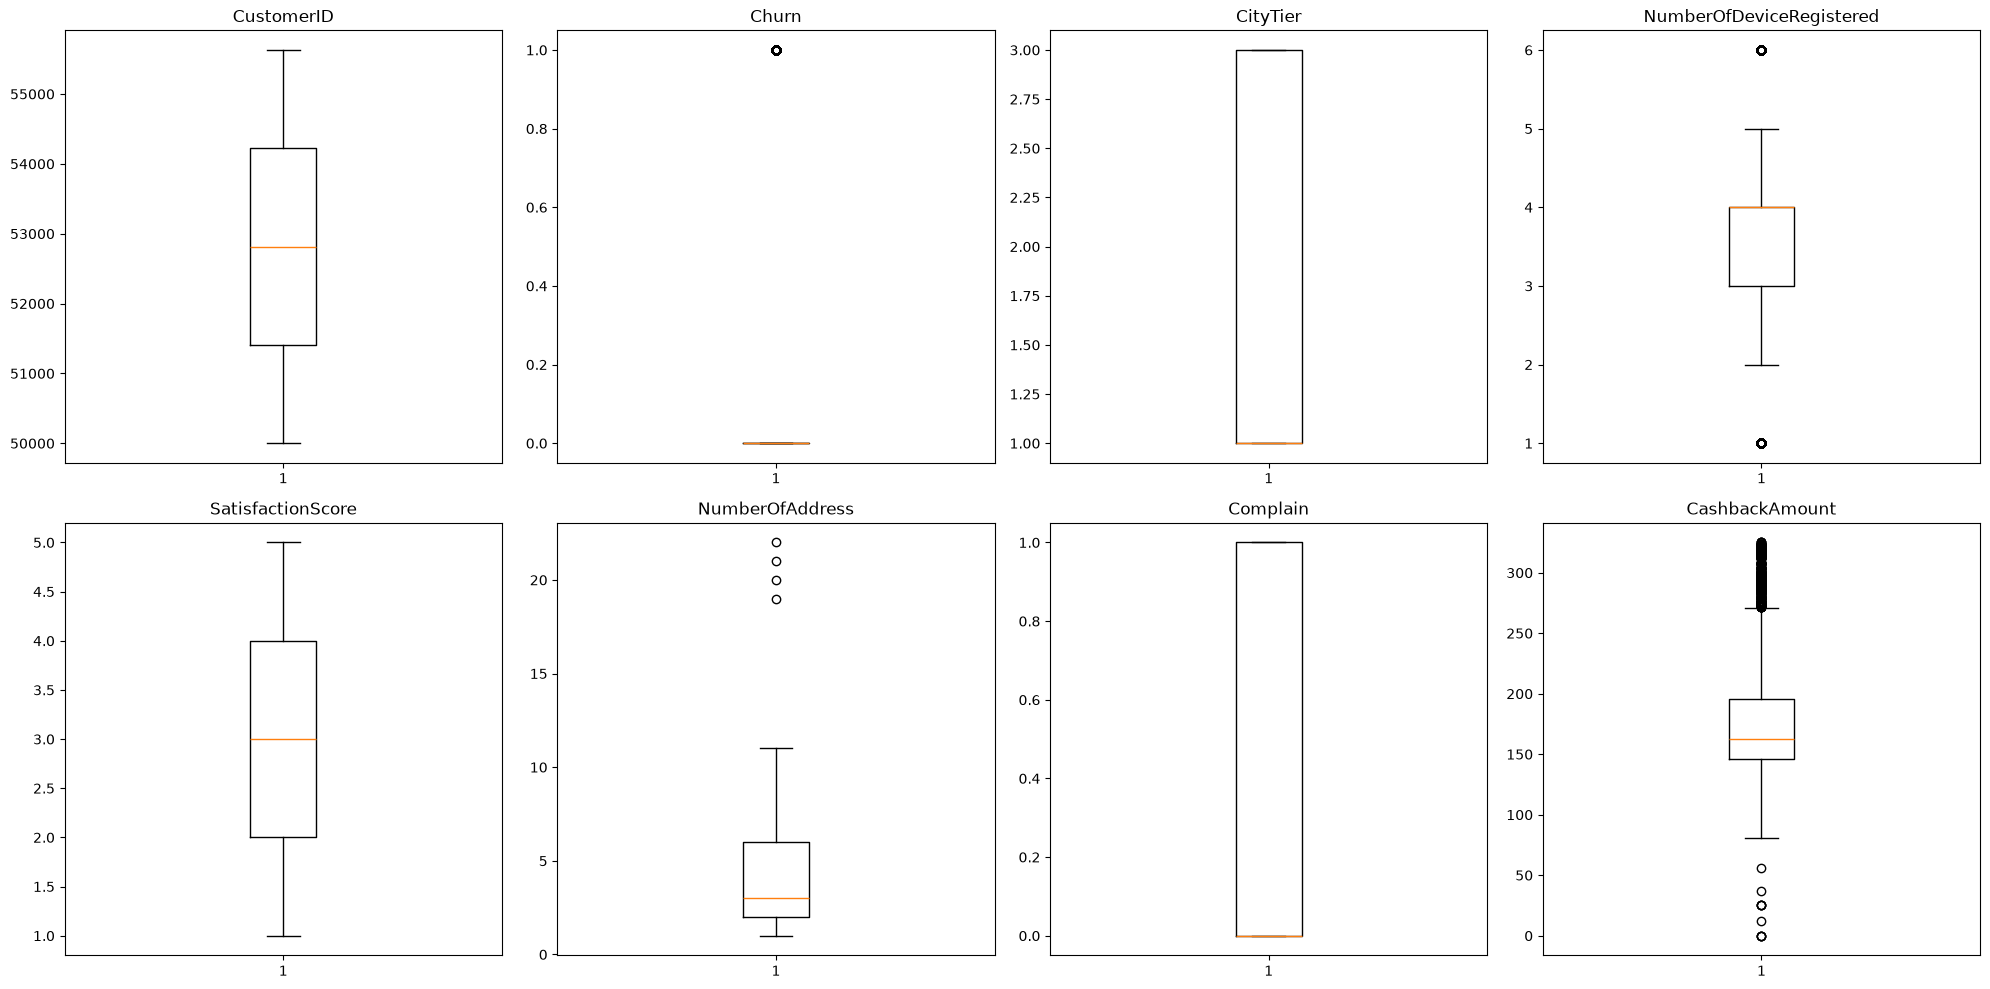

In [27]:
num_cols = dataset.select_dtypes(include='number').columns
n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(dataset[col].dropna())
    axes[i].set_title(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 6. Check Imbalance from Dataset

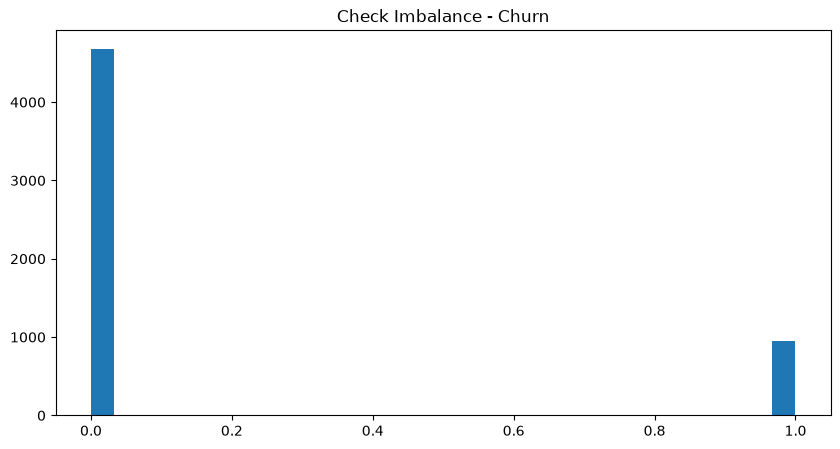

In [28]:
col = 'Churn'  
plt.figure(figsize=(10, 5))
plt.hist(dataset[col].dropna(), bins=30)
plt.title('Check Imbalance - Churn')
plt.show()